In [2]:
import pandas as pd

In [4]:
import numpy as np

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [10]:
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
boston_df = pd.read_csv(url)

In [13]:
X_boston = boston_df.drop('medv', axis=1)
y_boston = boston_df['medv']


In [16]:
scaler_boston = StandardScaler()
X_boston_scaled = scaler_boston.fit_transform(X_boston)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_boston_scaled, y_boston, test_size=0.20, random_state=42
)


In [30]:
print("Training set shape:",X_train.shape)
print("Testing set shape:",X_test.shape)

Training set shape: (404, 13)
Testing set shape: (102, 13)


In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [46]:
lr_preds=lr_model.predict(X_test)

In [48]:
mae = mean_absolute_error(y_test, lr_preds)
mse = mean_squared_error(y_test, lr_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lr_preds)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: 3.1891
Mean Squared Error: 24.2911
Root Mean Squared Error: 4.9286
R2 Score: 0.6688


In [63]:
from sklearn.svm import SVR

In [75]:
svr_model=SVR(kernel='rbf')

In [77]:
svr_model.fit(X_train,y_train)

SVR()

In [87]:
svr_preds=svr_model.predict(X_test)

In [89]:
mae = mean_absolute_error(y_test, svr_preds)
mse = mean_squared_error(y_test, svr_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, svr_preds)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: 2.7328
Mean Squared Error: 25.6930
Root Mean Squared Error: 5.0688
R2 Score: 0.6496


In [91]:
from sklearn.tree import DecisionTreeRegressor

In [98]:
dt_model=DecisionTreeRegressor(max_depth=5,random_state=42)

In [100]:
dt_model.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [102]:
dt_preds=dt_model.predict(X_test)

In [106]:
dt_mae=mean_absolute_error(y_test,dt_preds)

In [110]:
dt_mse=mean_squared_error(y_test,dt_preds)

In [112]:
dt_r2=r2_score(y_test,dt_preds)

In [114]:
dt_rmse=np.sqrt(dt_mse)

In [116]:
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: 2.7328
Mean Squared Error: 25.6930
Root Mean Squared Error: 5.0688
R2 Score: 0.6496


In [120]:
comparison = pd.DataFrame({
    'Model': ['SVR', 'Decision Tree'],
    'MAE': [mae, dt_mae],
    'RMSE': [rmse, dt_rmse],
    'R2 Score': [r2, dt_r2]
})

print("\\n===== Comparative Performance Analysis =====")
print(comparison)

\n===== Comparative Performance Analysis =====
           Model       MAE      RMSE  R2 Score
0            SVR  2.732769  5.068830  0.649643
1  Decision Tree  8.553907  2.924706  0.883357


In [122]:
import matplotlib.pyplot as plt

In [124]:
from sklearn.model_selection import learning_curve

In [150]:
train_sizes, train_scores, test_scores = learning_curve(
    estimator=lr_model,
    X=X_boston_scaled,
    y=y_boston,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='r2',
    random_state=42
)



In [152]:

train_mean = np.mean(train_scores, axis=1)
validation_mean = np.mean(validation_scores, axis=1)


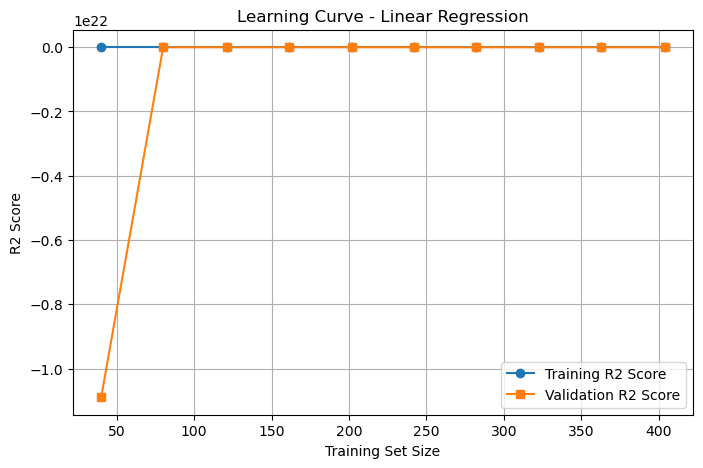

In [154]:


plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker='o', label='Training R2 Score')
plt.plot(train_sizes, validation_mean, marker='s', label='Validation R2 Score')
plt.title('Learning Curve - Linear Regression')
plt.xlabel('Training Set Size')
plt.ylabel('R2 Score')
plt.legend()
plt.grid(True)
plt.show()
